# Implementaciones alternativas.

**Descripción**.

El problema de flujo y transporte reactivo de 2 especies en equilibrio con el yeso en 1D desarrollada en la notebook `1_GWF_DFC_WMA_Imp.ipynb` se puede implementar en un archivo `.py`. Esto se hace en el archivo `3_GWF_DFC_WMA_Imp.py`. También, se puede usar la API de MODFLOW para tomar la información del flujo directamente de memoria y usar esta información en otros procesos; esto último se hace en el archivo `4_GWF_API_DFC_Imp_WMA.py`. Todo lo anterior se describe en esta notebook.

<a href="https://github.com/luiggix/RTWMA">RTWMA</a> © 2024-2026 by <a href="https://www.geofisica.unam.mx">IGF-UNAM</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc/4.0/">CC BY-NC 4.0</a><img src="https://mirrors.creativecommons.org/presskit/icons/cc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/by.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/nc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;">

# Ejecución en línea de comando.

En el archivo [`3_GWF_DFC_WMA_Imp.py`](3_GWF_DFC_WMA_Imp.py) se han implementado todos los pasos descritos en la notebook [`1_GWF_DFC_WMA_Imp.ipynb`](1_GWF_DFC_WMA_Imp.ipynb). La ejecución de esta implementación se realiza directamente en línea con el comando: 

* `python 1_GWF_DFC_WMA_Imp.py`

De igual manera se puede ejecutar en una celda como sigue:


Rutas y nombres de archivos
―――――――――――――――――――――――――――
                  mf6_exe = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6
                  mf6_dll = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll
          wma_working_dir = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE
               wma_wdname = workingDirectory.txt
               tr1d_ofile = gypsum_eq.out
           tr1d_ofile_dfc = gypsum_eq_dfc.out
               excel_data = comparativa_02.xlsx
                flow_name = flow
                  flow_ws = output_gwf_dfc_wma
                 tr1d_exe = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\TR_1D_oper.exe
     wma_lambdas_filename = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\input\gypsum_eq\WMA_lambdas_gypsum_eq.dat
                gypsum_eq = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\gypsum_eq.out
wma_workingDirectory_file = C:\Users\lui

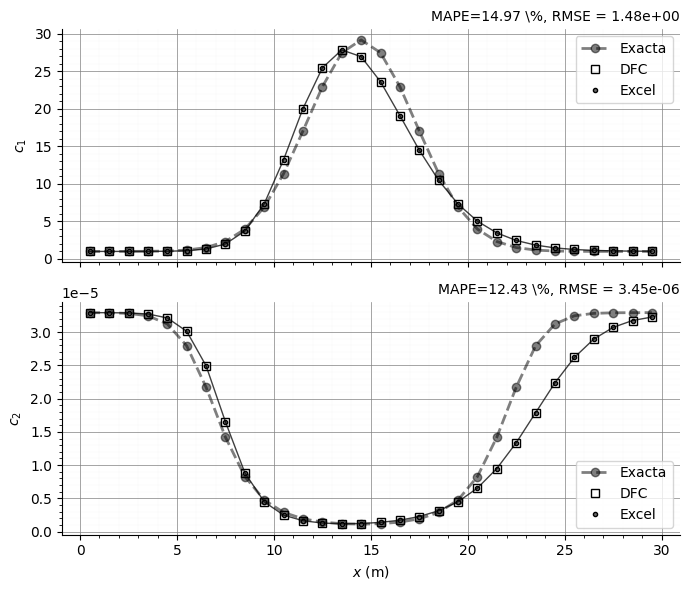

In [13]:
%run 3_GWF_DFC_WMA_Imp.py

# Optimización usando la API.

MODFLOW ofrece una API a través de la cual se puede acceder al contenido de las variables en memoria de una simulación. Usando esta API se puede ejecutar el modelo de flujo y en tiempo de ejecución recuperar los resultados del flujo (`head` y `q`) para posteriormente usarlos en el cálculo del transporte reactivo. La figura 1 muestra el flujo de información de esta implementación.

<figure>
  <img src="../figures/gwf_api_dfc_wma.svg" width=700px alt="dominio de estudio y condiciones" />
  <figcaption>

Figura 1. El flujo se resuelve usando GWF a través de la API de MODFLOW, los datos que requiere el modelo se proporcionan en diccionarios de Python (`dis`, `tdis`, `phys`, entre otros). GWF genera los resultados del flujo en arreglos que se pueden recuperar usando la API. Esta información es utilizada por DFC para generar los coeficientes de la discretización del modelo de transporte, dichos coeficientes se generan en memoria. El módulo `Lambdas` calcula las proporciones de mezcla ($\lambda$'s) y se guardan en archivos (`.dat`). Finalmente, el ejecutable `TR_1D_oper.exe` realiza los cálculos de transporte reactivo usando las proporciones de mezcla y guarda los resultados en archivos (`.out`). En esta última etapa, se realizan todos los pasos de tiempo del problema de transporte reactivo para un flujo estacionario.

</figcaption>
</figure>

La implementación de esta optimización se puede ver en el archivo [`4_GWF_API_DFC_Imp_WMA.py`](4_GWF_API_DFC_Imp_WMA.py). Se puede ejecutar en línea con el comando:

* `python 4_GWF_API_DFC_Imp_WMA.py`

y también en una celda como sigue:


Rutas y nombres de archivos
―――――――――――――――――――――――――――
                  mf6_exe = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6
                  mf6_dll = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll
          wma_working_dir = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE
               wma_wdname = workingDirectory.txt
               tr1d_ofile = gypsum_eq.out
           tr1d_ofile_dfc = gypsum_eq_dfc.out
               excel_data = comparativa_02.xlsx
                flow_name = flow
                  flow_ws = output_gwf_api_dfc_wma
                 tr1d_exe = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\TR_1D_oper.exe
     wma_lambdas_filename = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\input\gypsum_eq\WMA_lambdas_gypsum_eq.dat
                gypsum_eq = C:\Users\luiggi\Documents\GitSites\RTWMA\benchmarks\03_wma\RT-EXE\gypsum_eq.out
wma_workingDirectory_file = C:\Users

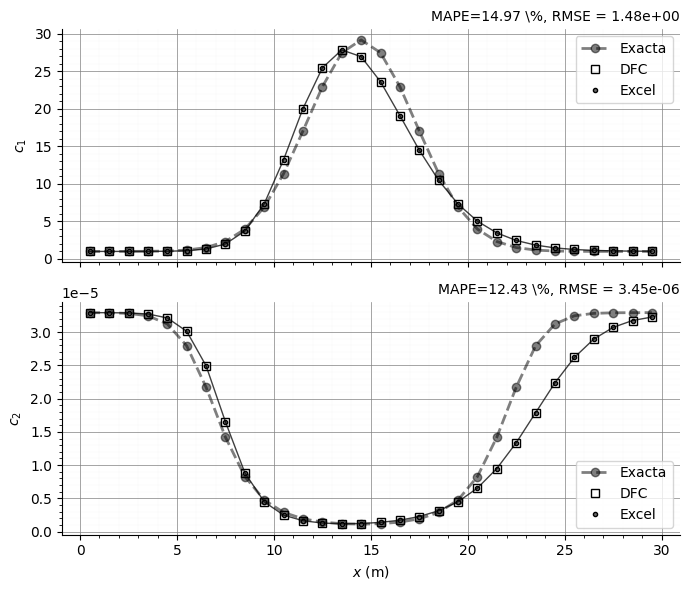

In [17]:
%run 4_GWF_API_DFC_Imp_WMA.py